# TraceWin distributions and explicit Python simulator run

This notebook first executes `visualize_distributions.ipynb` unchanged. It then runs `TraceWinSimulator` twice: once with the 18 explicit parameter values listed below, and once with `config.adige.default_params()`. Each run displays the final distribution with the same layout, beam-state table, and official score.


Running original viewer: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/visualize_distributions.ipynb


WORKSPACE   = /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace
CALC_DIR    = /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc
DST_INPUT   = /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/16O5.dst  (complete input distribution)
DST_OUTPUT  = /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc/part_dtl1.dst
PARTRAN_OUT = /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc/partran1.out
PNG_OUTPUT  = /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/distribution_plots
NPART_SIMULATED = 10,000
Loaded distributions:
  Initial input distribution 16O5.dst 16O5.dst       reservoir       159,682 particl

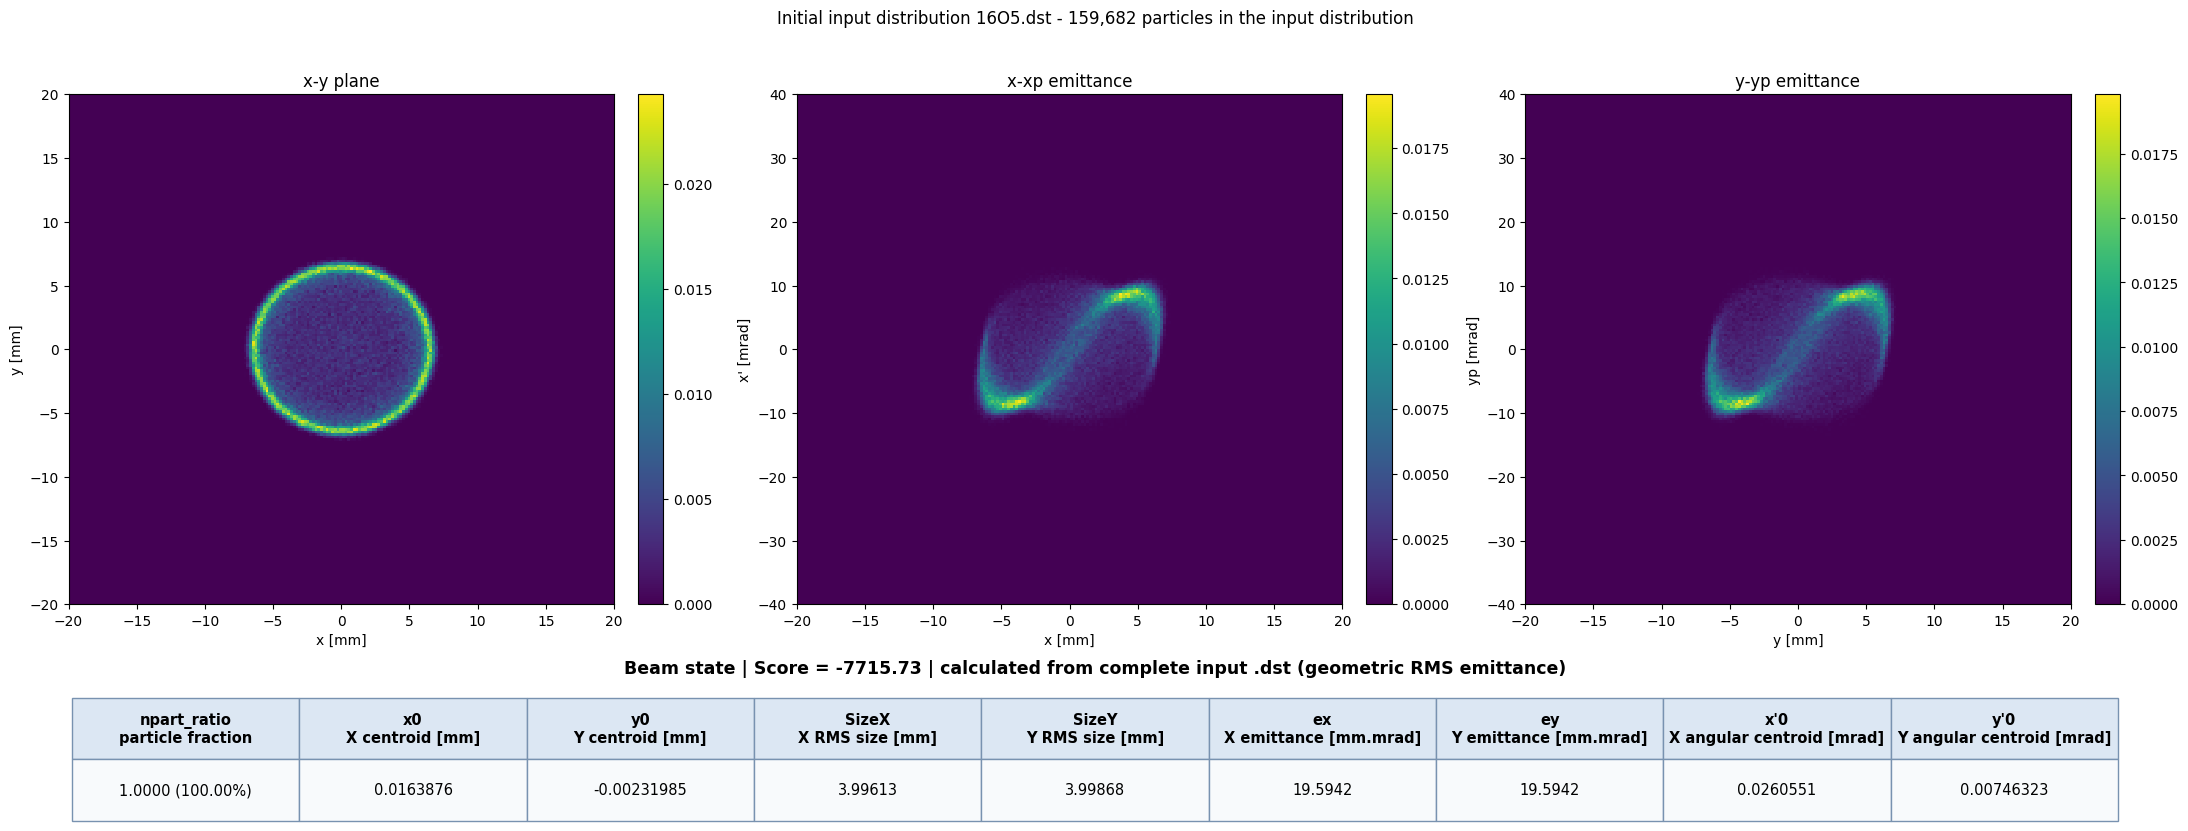

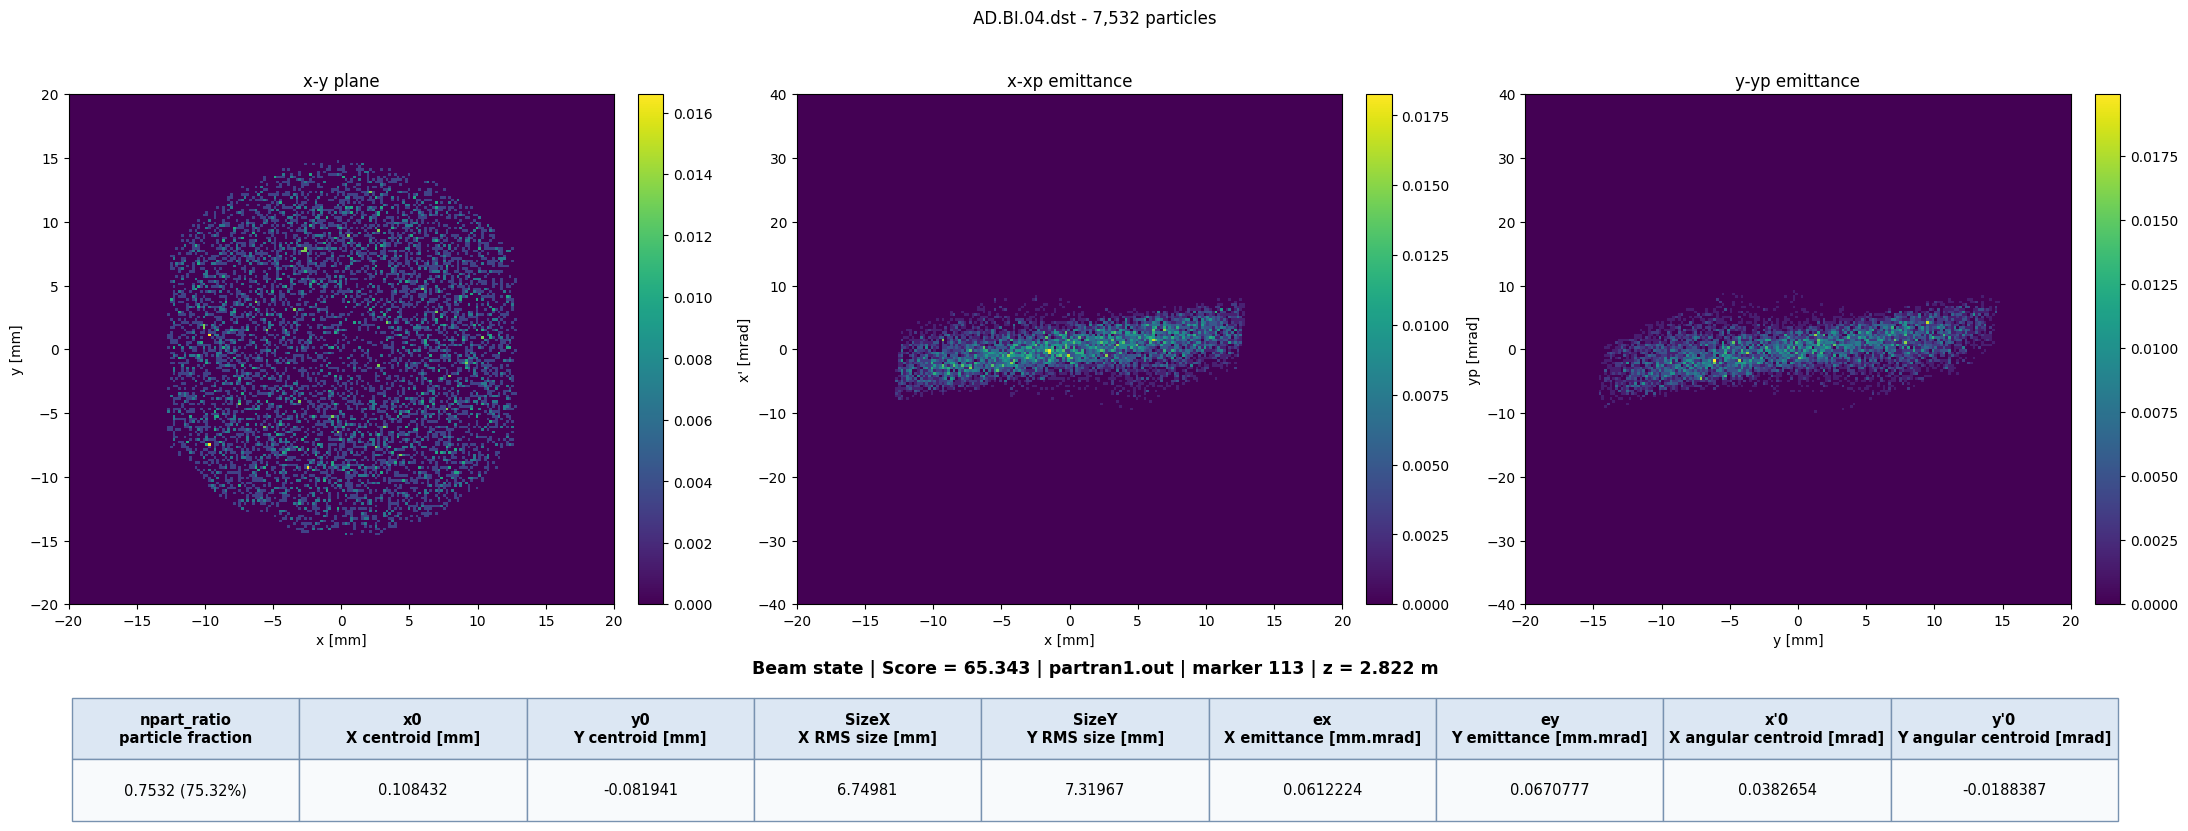

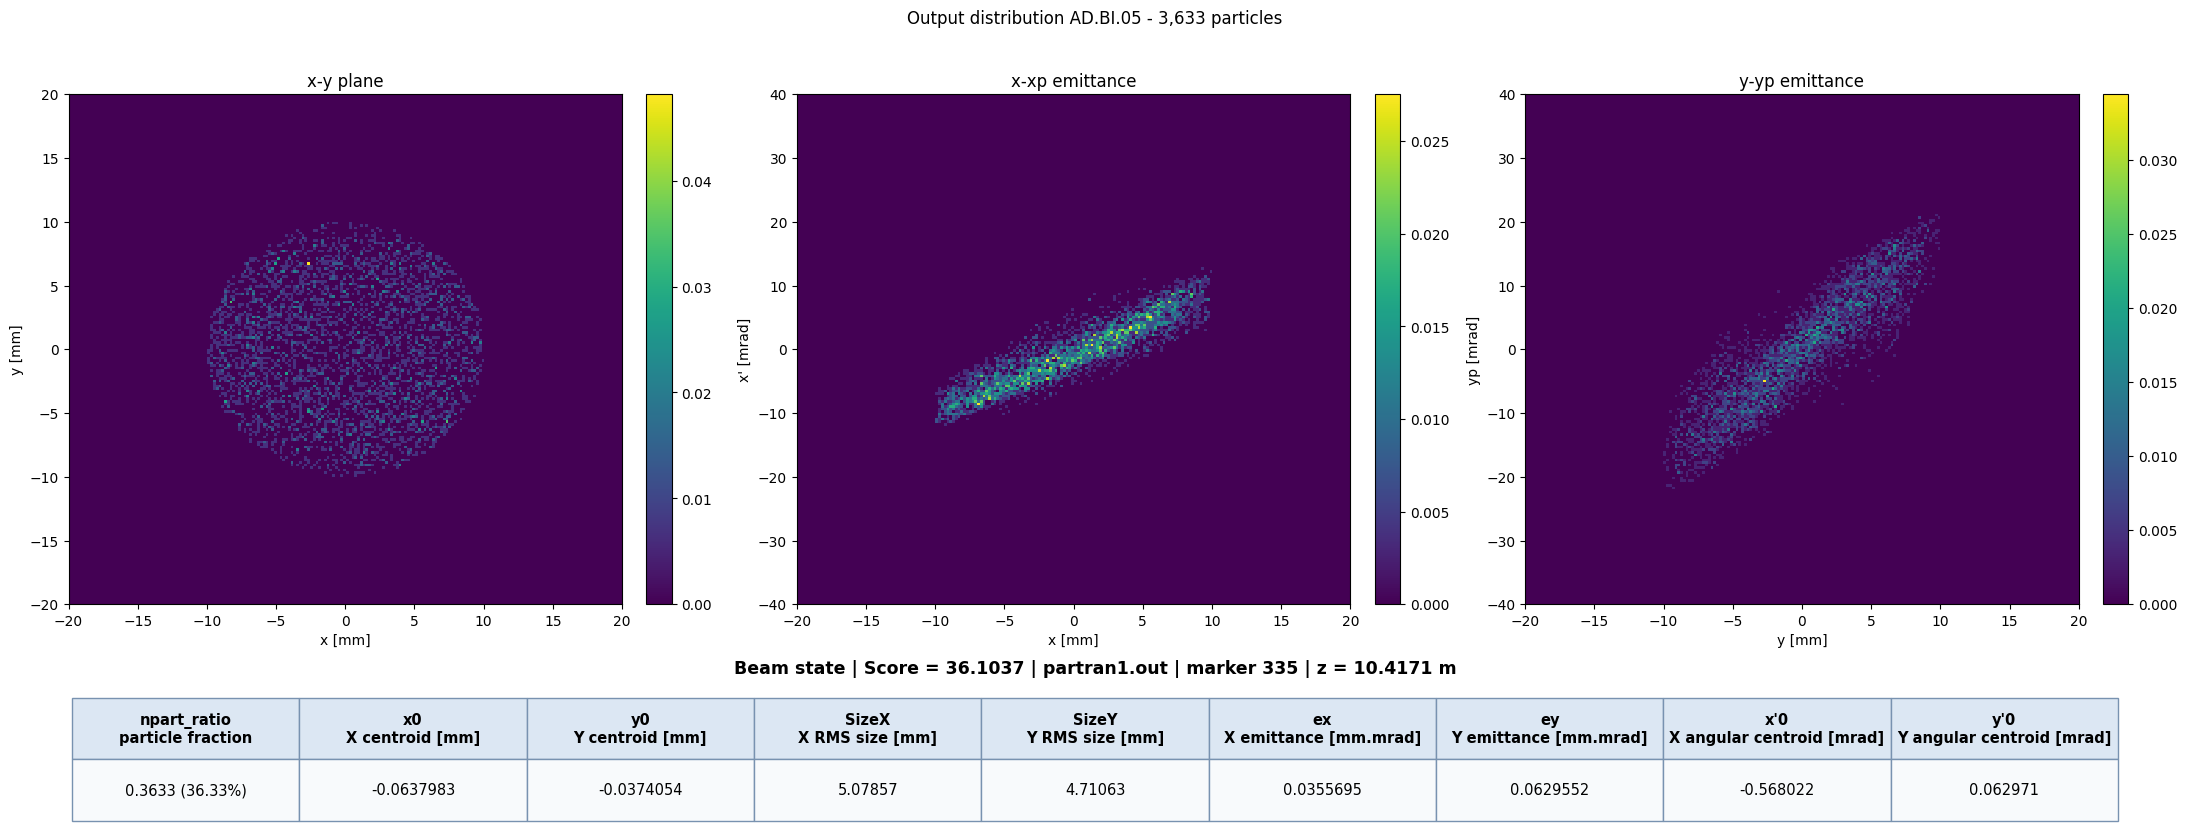

Saved distribution figures:
  /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/distribution_plots/distribution_00_16O5.dst.png
  /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/distribution_plots/distribution_01_AD.BI.04.dst.png
  /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/distribution_plots/distribution_02_part_dtl1.dst.png


Saved envelope figure: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/distribution_plots/beam_rms_envelope.png


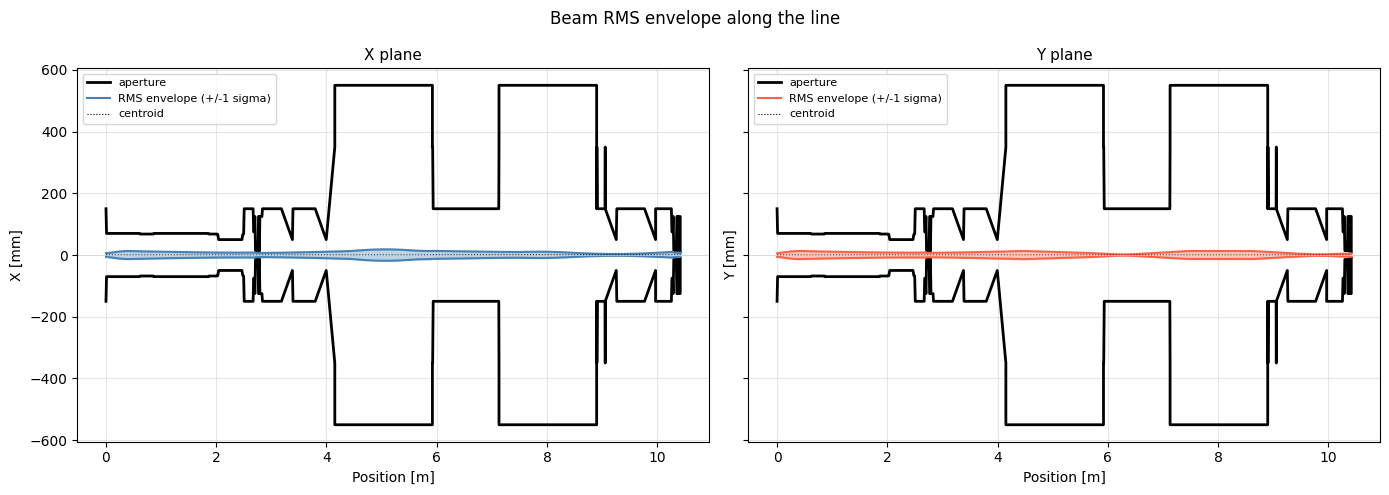

In [1]:
from pathlib import Path

start = Path.cwd().resolve()
repo_root = next(
    candidate for candidate in (start, *start.parents)
    if (candidate / 'beam_optimization' / '__init__.py').exists()
)
original_notebook = (
    repo_root / 'beam_optimization/env/tracewin_env/tracewin/visualize_distributions.ipynb'
)
print(f'Running original viewer: {original_notebook}')
get_ipython().run_line_magic('run', str(original_notebook))


## TraceWinSimulator run with the requested parameters

The values follow the current `config.adige.PARAMETERS` order.
`TraceWinSimulator` is called directly on the real project file, writing to its own
`python_parameter_run_calc/` subdirectory inside `TRACEWIN_WORKSPACE`; it never touches
`calc/`, `calc_debug_env/`, or `distribution_plots/` (it only resets the calc dir it was
given and removes stray `.cal`/`*_new.ini` files from the project directory). The
workspace's field-map files (hundreds of MB) are reused in place rather than copied,
which previously filled `/tmp` and crashed the run.


In [2]:
from beam_optimization.config.adige import PARAMETERS
from beam_optimization.env.tracewin_env.tracewin.tracewin_simulator import TraceWinSimulator

PARAMETER_VALUES = [
    0.43, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    -0.0462087, 0.0, 0.0, 0.0, 0.0, 0.0462087,
    0.0, 0.0, 0.0, -206.0,
]
if len(PARAMETER_VALUES) != len(PARAMETERS):
    raise ValueError(
        f'Expected {len(PARAMETERS)} values, got {len(PARAMETER_VALUES)}'
    )

python_params = {
    parameter.key: float(value)
    for parameter, value in zip(PARAMETERS, PARAMETER_VALUES)
}

python_calc_dir = TRACEWIN_WORKSPACE / 'python_parameter_run_calc'
python_project_file = TRACEWIN_WORKSPACE / 'CB_newMRMS_RFQ_Fields_1.ini'

print('Parameters passed to TraceWinSimulator:')
for parameter, value in zip(PARAMETERS, PARAMETER_VALUES):
    print(f'  {parameter.name:<12} {parameter.key:<14} = {value:.9g}')

python_simulator = TraceWinSimulator(
    project_file=str(python_project_file),
    calc_dir=str(python_calc_dir),
    timeout=180.0,
    retries=2,
)
python_result = python_simulator.simulate(python_params)
print(f'\nsuccess = {python_result.success}')
print(f'score   = {python_result.score_val:.9g}')
print(f'error   = {python_result.error}')
print(f'calc    = {python_calc_dir}')
if not python_result.success or python_result.final_beam is None:
    raise RuntimeError(f'TraceWinSimulator run failed: {python_result.error}')


Parameters passed to TraceWinSimulator:
  AD.SO.01     ele[2][5]      = 0.43
  AD.SO.02     ele[29][5]     = 0.1
  AD.MS.03.X   ele[38][1]     = 0
  AD.MS.03.Y   ele[38][2]     = 0
  AD.1EQ.01    ele[151][2]    = 0
  AD.MS.04.X   ele[162][1]    = 0
  AD.MS.04.Y   ele[162][2]    = 0
  AD.1EQ.02    ele[195][2]    = 0
  AD.D.02      ele[197][5]    = -0.0462087
  AD.EM.6      ele[200][6]    = 0
  AD.EM.8      ele[201][6]    = 0
  AD.EM.10     ele[202][6]    = 0
  AD.EM.12     ele[203][6]    = 0
  AD.D.03      ele[205][5]    = 0.0462087
  AD.1EQ.03    ele[225][2]    = 0
  AD.MS.05.X   ele[261][1]    = 0
  AD.MS.05.Y   ele[261][2]    = 0
  AD.1EQ.04    ele[280][2]    = -206



success = True
score   = 36.0553706
error   = None
calc    = /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/python_parameter_run_calc


## Final distribution produced by the Python run


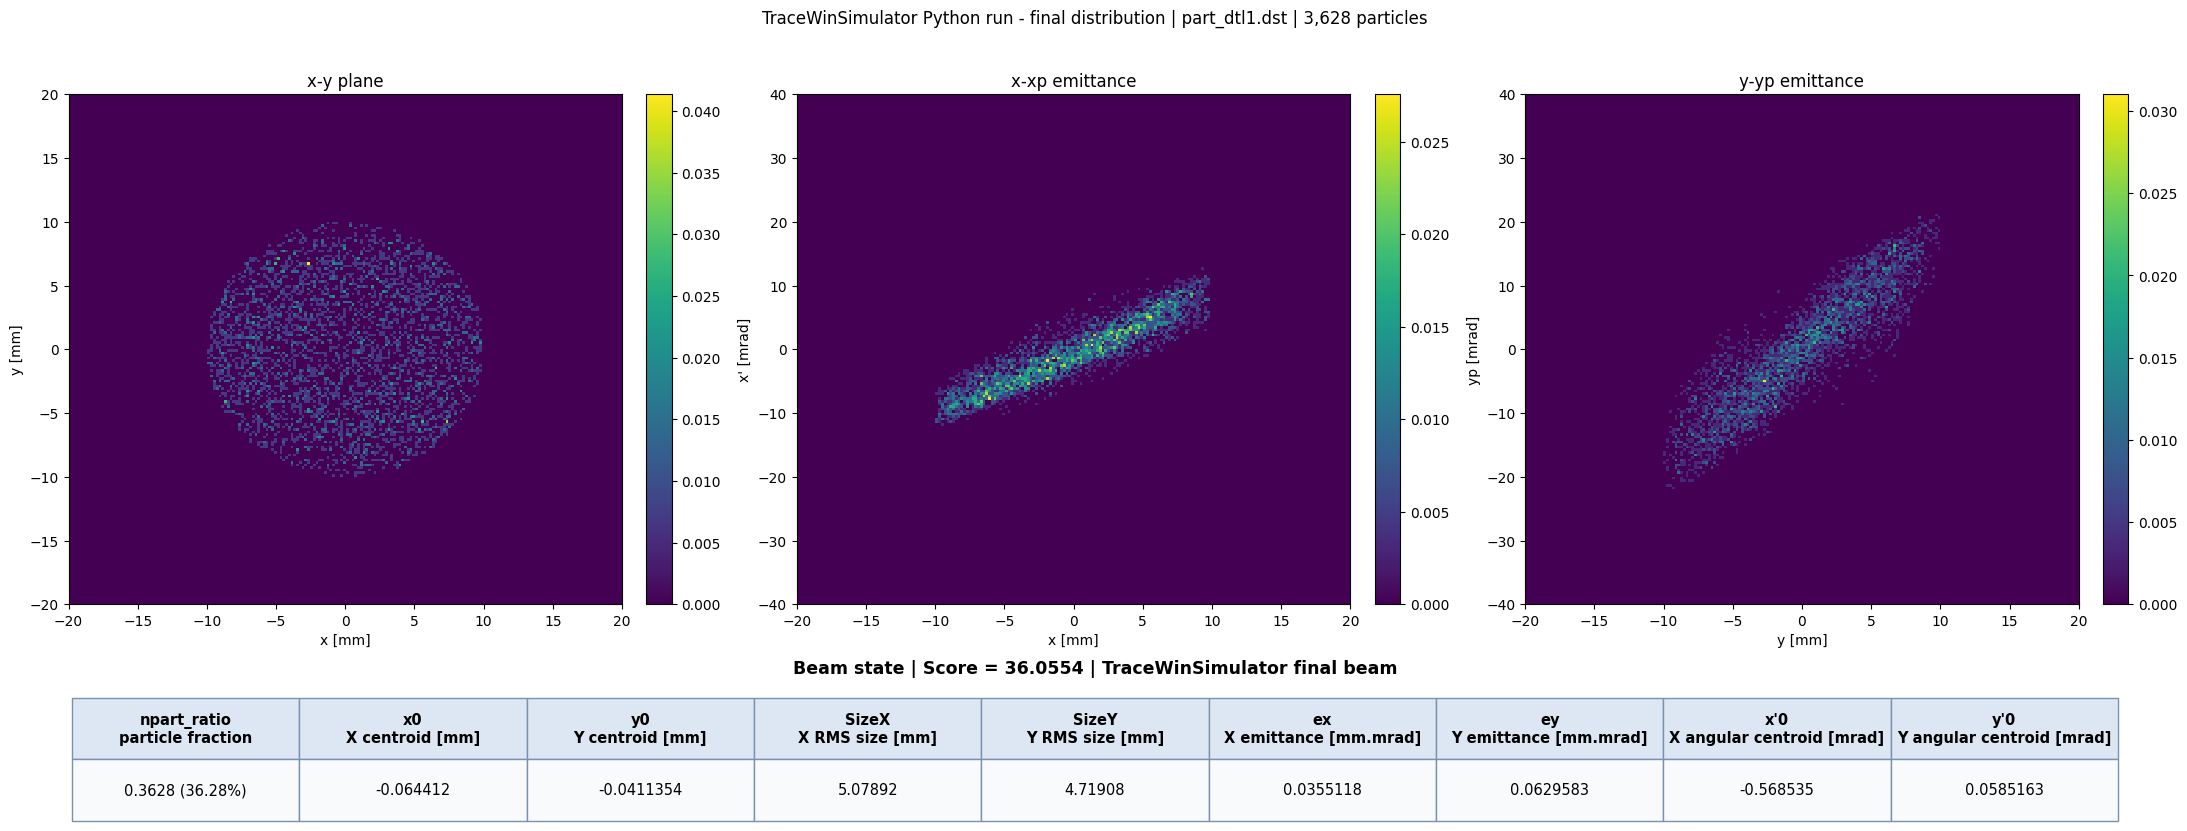

Saved Python-run figure: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/distribution_plots/python_run_final_distribution.png


In [3]:
python_dst_path = find_final_tracewin_dst_path(python_calc_dir)
if python_dst_path is None:
    raise FileNotFoundError(f'No final .dst found in {python_calc_dir}')

python_distribution = tracewin_distribution_from_dst(python_dst_path)
python_figure_path = IMAGE_OUTPUT_DIR / 'python_run_final_distribution.png'
python_fig = plot_tracewin_distribution_with_state(
    python_distribution,
    python_result.final_beam,
    python_result.score_val,
    state_source='TraceWinSimulator final beam',
    title=(
        'TraceWinSimulator Python run - final distribution '
        f'| {python_dst_path.name} | {len(python_distribution["x"]):,} particles'
    ),
    figure_name='TraceWinSimulator Python run final distribution',
    bins=200,
    xy_range_mm=20,
    angle_range_mrad=40,
    aperture_radius_mm=None,
    figsize=(22, 8.5),
    save_path=python_figure_path,
    show=False,
)
plt.show()
print(f'Saved Python-run figure: {python_figure_path}')


## TraceWinSimulator run with `config.adige` default parameters

Same procedure as above, but with `default_params()` (the `ParameterSpec.default` for every parameter) instead of the explicit `PARAMETER_VALUES` list, so the two Python runs can be compared to each other as well as to the GUI run.


In [4]:
from beam_optimization.config.adige import default_params

default_python_params = default_params()
default_calc_dir = TRACEWIN_WORKSPACE / 'python_default_run_calc'

print('Default parameters passed to TraceWinSimulator:')
for parameter in PARAMETERS:
    print(f'  {parameter.name:<12} {parameter.key:<14} = {default_python_params[parameter.key]:.9g}')

default_simulator = TraceWinSimulator(
    project_file=str(python_project_file),
    calc_dir=str(default_calc_dir),
    timeout=180.0,
    retries=2,
)
default_result = default_simulator.simulate(default_python_params)
print(f'\nsuccess = {default_result.success}')
print(f'score   = {default_result.score_val:.9g}')
print(f'error   = {default_result.error}')
print(f'calc    = {default_calc_dir}')
if not default_result.success or default_result.final_beam is None:
    raise RuntimeError(f'TraceWinSimulator run failed: {default_result.error}')


Default parameters passed to TraceWinSimulator:
  AD.SO.01     ele[2][5]      = 0.43
  AD.SO.02     ele[29][5]     = 0.1
  AD.MS.03.X   ele[38][1]     = 0
  AD.MS.03.Y   ele[38][2]     = 0
  AD.1EQ.01    ele[151][2]    = 0
  AD.MS.04.X   ele[162][1]    = 0
  AD.MS.04.Y   ele[162][2]    = 0
  AD.1EQ.02    ele[195][2]    = 0
  AD.D.02      ele[197][5]    = -0.0462087
  AD.EM.6      ele[200][6]    = 0
  AD.EM.8      ele[201][6]    = 0
  AD.EM.10     ele[202][6]    = 0
  AD.EM.12     ele[203][6]    = 0
  AD.D.03      ele[205][5]    = 0.0462087
  AD.1EQ.03    ele[225][2]    = 0
  AD.MS.05.X   ele[261][1]    = 0
  AD.MS.05.Y   ele[261][2]    = 0
  AD.1EQ.04    ele[280][2]    = -206



success = True
score   = 36.1036676
error   = None
calc    = /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/python_default_run_calc


## Final distribution produced by the default-parameters Python run


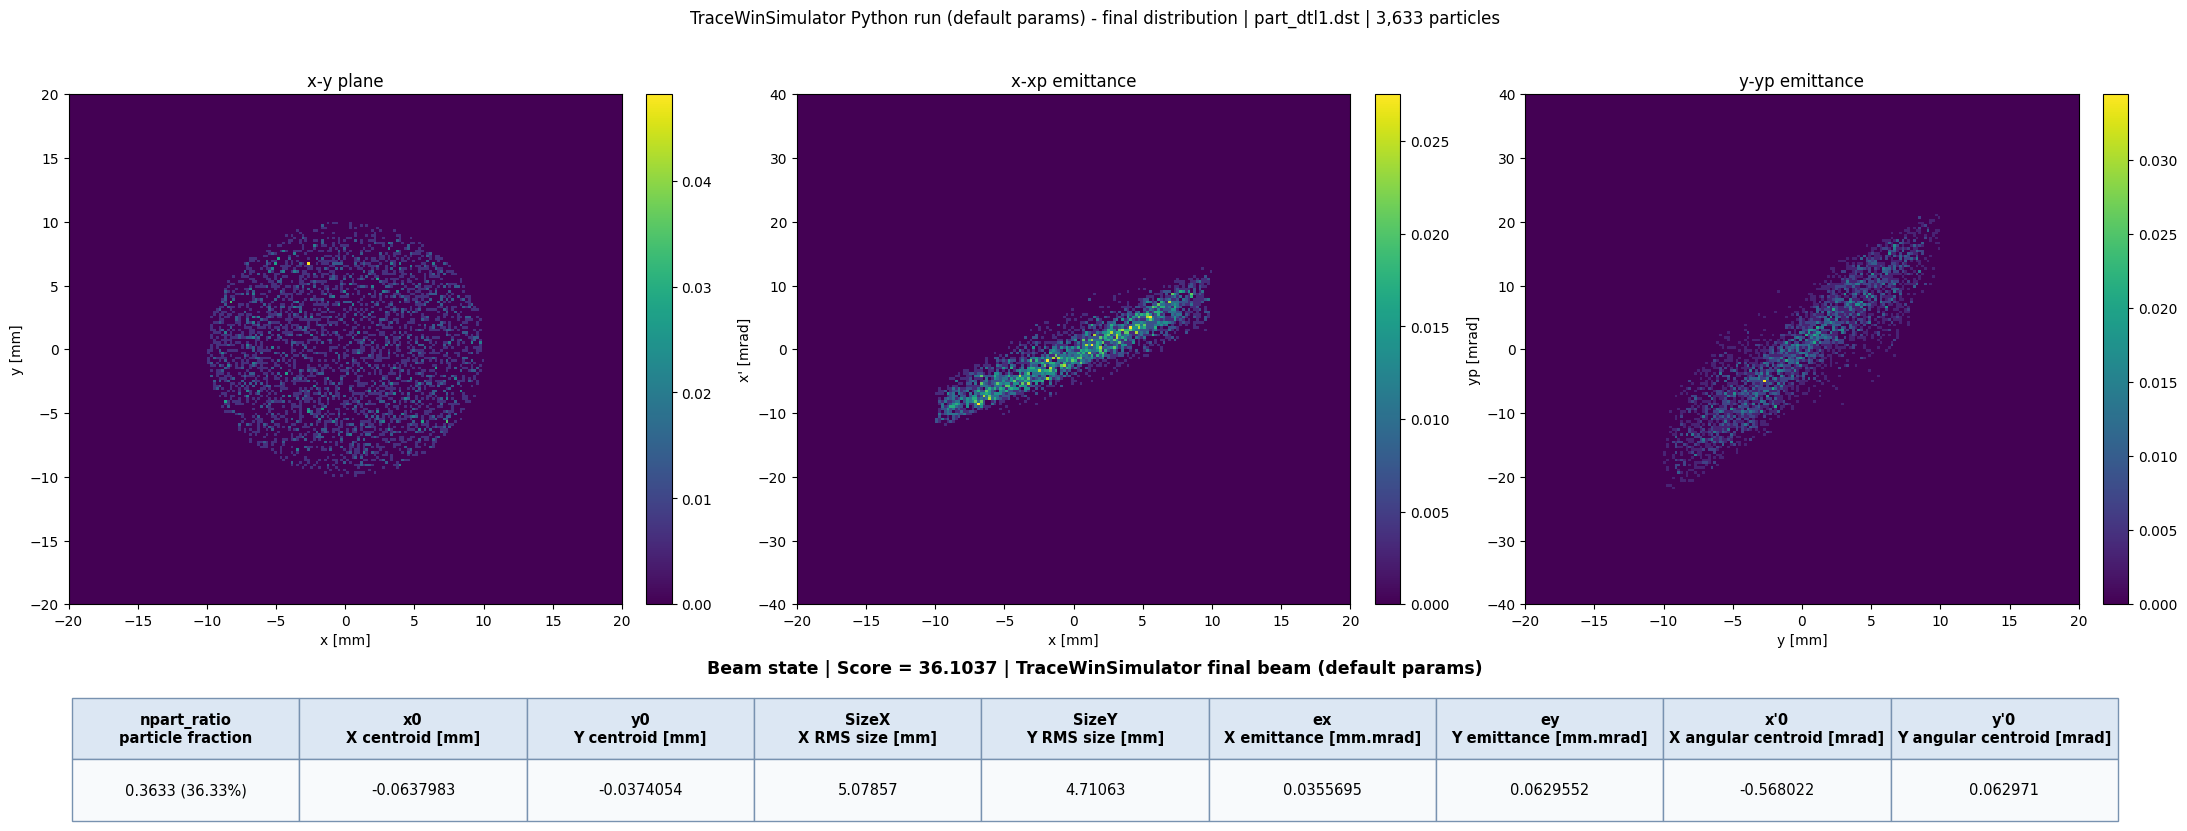

Saved default-parameters Python-run figure: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/distribution_plots/python_default_run_final_distribution.png


In [5]:
default_dst_path = find_final_tracewin_dst_path(default_calc_dir)
if default_dst_path is None:
    raise FileNotFoundError(f'No final .dst found in {default_calc_dir}')

default_distribution = tracewin_distribution_from_dst(default_dst_path)
default_figure_path = IMAGE_OUTPUT_DIR / 'python_default_run_final_distribution.png'
default_fig = plot_tracewin_distribution_with_state(
    default_distribution,
    default_result.final_beam,
    default_result.score_val,
    state_source='TraceWinSimulator final beam (default params)',
    title=(
        'TraceWinSimulator Python run (default params) - final distribution '
        f'| {default_dst_path.name} | {len(default_distribution["x"]):,} particles'
    ),
    figure_name='TraceWinSimulator Python run (default params) final distribution',
    bins=200,
    xy_range_mm=20,
    angle_range_mrad=40,
    aperture_radius_mm=None,
    figsize=(22, 8.5),
    save_path=default_figure_path,
    show=False,
)
plt.show()
print(f'Saved default-parameters Python-run figure: {default_figure_path}')


## Hardcoded parameters vs. default parameters — score comparison

This comparison reuses the two official `TraceWinSimulator` scores computed above; it does not launch another simulation.


In [ ]:
hardcoded_score = float(python_result.score_val)
default_score = float(default_result.score_val)
score_difference = hardcoded_score - default_score

score_labels = ['Hardcoded parameters', 'Default parameters']
score_values = [hardcoded_score, default_score]
score_colors = ['#4c78a8', '#9d9d9d']

score_fig, score_axis = plt.subplots(figsize=(8.5, 5.2))
score_bars = score_axis.bar(
    score_labels,
    score_values,
    color=score_colors,
    width=0.58,
    alpha=0.9,
)
score_axis.axhline(0.0, color='#333333', linewidth=0.9)
for bar, value in zip(score_bars, score_values):
    score_axis.annotate(
        f'{value:.6g}',
        xy=(bar.get_x() + bar.get_width() / 2.0, value),
        xytext=(0, 6 if value >= 0.0 else -6),
        textcoords='offset points',
        ha='center',
        va='bottom' if value >= 0.0 else 'top',
        fontsize=11,
        fontweight='bold',
    )
score_axis.text(
    0.5,
    0.96,
    f'Δ score (hardcoded - default) = {score_difference:+.6g}',
    transform=score_axis.transAxes,
    ha='center',
    va='top',
    fontsize=11,
    bbox={'boxstyle': 'round,pad=0.4', 'facecolor': 'white', 'alpha': 0.9},
)
score_axis.set_title('TraceWin score comparison')
score_axis.set_ylabel('Official beam-quality score')
score_axis.grid(axis='y', alpha=0.25)
score_axis.margins(y=0.22)
score_fig.tight_layout()

score_comparison_path = IMAGE_OUTPUT_DIR / 'python_hardcoded_vs_default_score.png'
score_fig.savefig(score_comparison_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved score-comparison figure: {score_comparison_path}')
